In [1]:
import pandas as pd
import mlflow
import mlflow.sklearn
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, precision_score, recall_score, 
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from mlflow.models.signature import infer_signature

In [2]:
df = pd.read_csv('../data/rewiew_restorants_classical.csv')

In [3]:
df

,text,rating,setniment,text_clean
0,Глубинка страны во всех своих проявлениях. Асс...,4.0,0,глубинка страна весь свой проявлениях ассортим...
1,"5 из 5🖤 Пил кофе и в Риме, и в Париже, но вку...",5.0,0,<NUMBER> <NUMBER> пить кофе риме париже вкусне...
2,"Не очень удобное расположение, от метро идти м...",4.0,0,очень удобный расположение метро идти мина <NU...
3,"Самый большой плюс это месторасположение, набе...",2.0,1,самый большой плюс это месторасположение набер...
4,Добрый день! Сегодня во второй раз посетили с ...,5.0,0,добрый день сегодня второй посетить дочка рест...
...,...,...,...,...
103087,"Вкуснейшая еда, отличный персонал, ребята моло...",5.0,0,вкусный еда отличный персонал ребята молодцы д...
103088,"Залетели ночью с друзьями, разбудили работника...",1.0,1,залететь ночью друзьями разбудить работника сд...
103089,Очень вкусная пицца. Нравится их система лояль...,5.0,0,очень вкусный пицца нравиться система лояльнос...
103090,"Пицца детям понравилась, интерьер очень интере...",5.0,0,пицца ребёнок понравилась интерьер очень интер...


In [4]:
df_ML = df[['text_clean', 'setniment']]
X, Y = df_ML['text_clean'], df_ML['setniment']
X_train,  X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42, shuffle=True, stratify=Y)
X_test, X_val, Y_test, Y_val = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42, stratify=Y_temp, shuffle=True)

In [5]:
df_ML

,text_clean,setniment
0,глубинка страна весь свой проявлениях ассортим...,0
1,<NUMBER> <NUMBER> пить кофе риме париже вкусне...,0
2,очень удобный расположение метро идти мина <NU...,0
3,самый большой плюс это месторасположение набер...,1
4,добрый день сегодня второй посетить дочка рест...,0
...,...,...
103087,вкусный еда отличный персонал ребята молодцы д...,0
103088,залететь ночью друзьями разбудить работника сд...,1
103089,очень вкусный пицца нравиться система лояльнос...,0
103090,пицца ребёнок понравилась интерьер очень интер...,0


# Naive Bayes

2026/01/02 02:25:51 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/02 02:25:51 INFO mlflow.store.db.utils: Updating database tables
2026/01/02 02:25:51 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/02 02:25:51 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/02 02:25:51 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/02 02:25:51 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/02 02:25:51 INFO mlflow.tracking.fluent: Experiment with name 'ClassicalNLPSentiment' does not exist. Creating a new experiment.


Precision(-): 0.8415, Recall(-): 0.7988, F1(-): 0.8196
ROC-AUC: 0.9718


2026/01/02 02:26:06 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/02 02:26:06 INFO mlflow.store.db.utils: Updating database tables
2026/01/02 02:26:06 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/02 02:26:06 INFO alembic.runtime.migration: Will assume non-transactional DDL.
Successfully registered model 'NB_TFIDF_Model'.
Created version '1' of model 'NB_TFIDF_Model'.


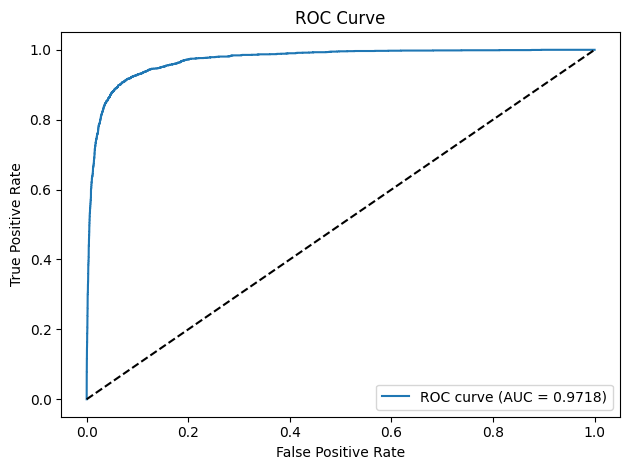

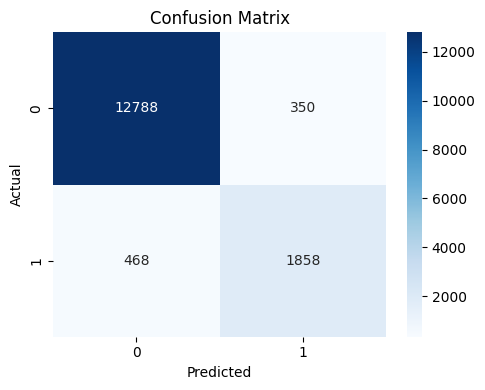

In [6]:
alpha_fixed = 0.1
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1,2))),
    ("nb", MultinomialNB(alpha=alpha_fixed))
])

registered_model_name = "NB_TFIDF_Model"
experiment_name = 'ClassicalNLPSentiment'

mlflow.set_experiment(experiment_name)

with mlflow.start_run(run_name=f"NB_alpha={alpha_fixed}"):

    pipeline.fit(X_train, Y_train)

    y_train_pred = pipeline.predict(X_train)
    y_val_pred = pipeline.predict(X_val)
    y_test_pred  = pipeline.predict(X_test)
    
    y_val_prob = pipeline.predict_proba(X_val)[:,1]
    y_test_prob = pipeline.predict_proba(X_test)[:,1]


    precision_neg_val = precision_score(Y_val, y_val_pred, pos_label=1)
    recall_neg_val    = recall_score(Y_val, y_val_pred, pos_label=1)
    f1_neg_val        = f1_score(Y_val, y_val_pred, pos_label=1)
    roc_auc_val      = roc_auc_score(Y_val, y_val_prob)

    precision_neg = precision_score(Y_test, y_test_pred, pos_label=1)
    recall_neg    = recall_score(Y_test, y_test_pred, pos_label=1)
    f1_neg        = f1_score(Y_test, y_test_pred, pos_label=1)
    roc_auc      = roc_auc_score(Y_test, y_test_prob)


    mlflow.log_param("alpha", alpha_fixed)


    mlflow.log_metric("precision_negative_val", precision_neg_val)
    mlflow.log_metric("recall_negative_val", recall_neg_val)
    mlflow.log_metric("f1_negative_val", f1_neg_val)
    mlflow.log_metric("roc_auc_val", roc_auc_val)

    mlflow.log_metric("precision_negative", precision_neg)
    mlflow.log_metric("recall_negative", recall_neg)
    mlflow.log_metric("f1_negative", f1_neg)
    mlflow.log_metric("roc_auc", roc_auc)

    print(f"Precision(-): {precision_neg:.4f}, Recall(-): {recall_neg:.4f}, F1(-): {f1_neg:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    fpr, tpr, thresholds = roc_curve(Y_test, y_test_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("../artifacts/images/NB_roc_curve.png")
    mlflow.log_artifact("../artifacts/images/NB_roc_curve.png")
    

    cm = confusion_matrix(Y_test, y_test_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig("../artifacts/images/NB_confusion_matrix.png")
    mlflow.log_artifact("../artifacts/images/NB_confusion_matrix.png")

    example_input = X_train[:5].to_frame()
    signature = infer_signature(X_train, pipeline.predict(X_train[:5]))
    
    mlflow.sklearn.log_model(
        sk_model=pipeline,
        name="nb_pipeline",
        signature=signature,
        input_example=example_input,
        registered_model_name=registered_model_name,
        metadata={"dataset_name": "classicalCleanTextOverview.csv"}
    )

    dataset_path = "../artifacts/datasets/classicalCleanTextOverview.csv"
    df_ML.to_csv(dataset_path, index=False)
    mlflow.log_artifact(dataset_path, artifact_path='dataset')

ВЫВОДЫ:
Наивный Байесовский классификатор показал себя очень хорошо:
- Precision(-): 0.8415, 
- Recall(-): 0.7988, 
- F1(-): 0.8196
- ROC-AUC: 0.9718

## SVM